# 08-GPU Scheduling & Allocation (NVIDIA GPU Operator)

Lesson 07 assumed a training job's GPUs were already assigned and asked how to recover *that* job's state after a failure. This lesson steps back one stage earlier: before any process can even start, the Kubernetes scheduler has to decide *which physical GPUs, on which physical nodes* a job gets -- and that decision is not a simple "is a GPU free" check. A pod requesting 4 GPUs placed on 4 different nodes connected only by a slow inter-node network will run drastically slower than the same 4 GPUs placed on one node's NVLink-connected set, even though both placements satisfy "4 GPUs available."

The **NVIDIA GPU Operator** exposes GPUs as a schedulable Kubernetes resource (`nvidia.com/gpu`) and, together with node labels, taints, and topology metadata, gives the scheduler the raw material to make a *topology-aware* placement decision rather than a purely count-based one. Getting this right is a genuine combinatorial optimization problem: a multi-dimensional bin-packing filter stage followed by an interconnect-cost scoring stage, exactly mirroring (and extending) the two-phase filter-then-score architecture the real `kube-scheduler` runs on every pod.

We will build a small simulated cluster with real GPU topology structure, implement the filter (taints/tolerations, resource fit) and score (interconnect cost, fragmentation) phases in Python, and write genuine Kubernetes YAML for node selectors and taints -- the tool for this lesson is the **NVIDIA GPU Operator**.

## 1. The Combinatorics of Topology-Aware GPU Scheduling

### GPU Allocation as Multi-Dimensional Bin Packing

A cluster of nodes $\mathcal{N} = \{n_1, \dots, n_M\}$, each with a capacity vector $\vec{c}_{n} = (\text{gpu}_n, \text{cpu}_n, \text{mem}_n)$, must place a set of pods $\mathcal{P}$, each with a demand vector $\vec{d}_p$, such that for every node:

$$\sum_{p \,\in\, \text{assigned}(n)} \vec{d}_p \;\le\; \vec{c}_n \quad \text{(component-wise)}$$

This is **vector bin packing**, a generalization of the classical (1-D) bin-packing problem that is NP-hard even for a single resource dimension. Real schedulers do not solve it optimally; they run a polynomial-time *filter* stage (feasibility) followed by a *score* stage (a greedy heuristic such as best-fit), exactly the two phases we implement below.

### The Filter Phase as Constraint Satisfaction

Before any scoring happens, a node $n$ is filtered **out** unless it satisfies every hard constraint. Taints/tolerations are a boolean predicate: node $n$ with taint set $T_n$ is feasible for pod $p$ with toleration set $L_p$ iff

$$T_n \subseteq L_p$$

i.e. every taint the node declares must be explicitly tolerated (an untainted node, $T_n = \emptyset$, is trivially feasible for any pod). Node-selector labels add a second predicate, $R_p \subseteq \text{Labels}(n)$ (every required label must be present). Only nodes satisfying **both** predicates *and* the resource-fit inequality above enter the scoring phase:

$$\text{Feasible}(n, p) \iff T_n \subseteq L_p \;\land\; R_p \subseteq \text{Labels}(n) \;\land\; \vec{d}_p \le \vec{c}_n - \vec{u}_n$$

where $\vec{u}_n$ is the node's currently-used capacity.

### Interconnect Cost and Topology-Aware Scoring

GPUs are not interchangeable once selected -- pairwise communication cost depends on the physical link tier between them. Define a tier cost function for two GPUs $g_i, g_j$:

$$\text{cost}(g_i, g_j) = \begin{cases} 0 & \text{same GPU} \\ 1 & \text{NVLink (same node, same switch)} \\ 4 & \text{PCIe (same node, cross-socket)} \\ 16 & \text{cross-node network} \end{cases}$$

The chosen exponential-ish scale reflects the real order-of-magnitude bandwidth gap between tiers (NVLink $\sim$ 600 GB/s, PCIe $\sim$ 32 GB/s, typical inter-node fabric $\sim$ 25-100 Gb/s). For a candidate GPU set $S$ of size $k$ satisfying a job's request, the placement's total interconnect cost is the sum over all pairs:

$$\text{TotalCost}(S) = \sum_{\{g_i, g_j\} \subset S} \text{cost}(g_i, g_j)$$

and the scheduler prefers the feasible candidate set minimizing $\text{TotalCost}(S)$ -- this is precisely the quantity that determines Lesson 05's ring all-reduce wall-clock time in practice, even though the ring-cost *formula* itself only depends on parameter count.

### Fragmentation as a Stranded-Capacity Metric

A greedy allocator that ignores packing quality can leave a cluster **fragmented**: capacity exists in aggregate but no single node has enough contiguous free GPUs to satisfy any pending request. Define the fragmentation metric over free-capacity vector $\vec{f}_n$ per node and minimum job size $k$:

$$\text{Stranded}(\mathcal{N}, k) = \sum_{n \,\in\, \mathcal{N}} \vec{f}_n \cdot \mathbb{1}[\vec{f}_n < k]$$

the total free GPU count sitting on nodes that individually cannot satisfy even the smallest realistic job -- capacity that is technically "available" cluster-wide but operationally worthless until something is rescheduled or drained.

## 2. Imperative Execution: A Filter-Then-Score GPU Scheduler

We build a small cluster with real intra-node GPU topology (NVLink pairs vs. PCIe-only), define taints and a multi-GPU job's tolerations and resource request, then implement and run the filter and score phases from Section 1 -- while also writing a genuine Kubernetes `nodeSelector`/`tolerations` manifest fragment, since the `kubernetes` client and a live cluster are not available in this sandbox.

In [1]:
# Required installations: pip install pyyaml (nvidia-device-plugin / gpu-operator require a real GPU cluster)

import os
import yaml

print("--- 🚀 Initializing Topology-Aware GPU Scheduling Sandbox ---")

# 1. A small cluster: 4 nodes, each with 4 GPUs, two NVLink-paired within each node,
#    plus one node tainted for a dedicated team.
cluster = {
    "node-a": {"gpus": 4, "nvlink_groups": [[0, 1], [2, 3]], "taints": [], "labels": {"gpu-type": "a100"}},
    "node-b": {"gpus": 4, "nvlink_groups": [[0, 1], [2, 3]], "taints": [], "labels": {"gpu-type": "a100"}},
    "node-c": {"gpus": 4, "nvlink_groups": [[0, 1], [2, 3]], "taints": ["dedicated=ml-team:NoSchedule"], "labels": {"gpu-type": "h100"}},
    "node-d": {"gpus": 2, "nvlink_groups": [[0, 1]], "taints": [], "labels": {"gpu-type": "a100"}},
}
# GPUs already in use elsewhere in the cluster (simulating a partially-loaded cluster)
used = {"node-a": [0], "node-b": [], "node-c": [], "node-d": [0, 1]}

job_request = {"gpu_count": 2, "tolerations": [], "node_selector": {}}

print(f"   ✅ Simulated cluster: {len(cluster)} nodes, {sum(n['gpus'] for n in cluster.values())} total GPUs")
print(f"   ✅ Job request: {job_request['gpu_count']} GPUs, tolerations={job_request['tolerations']}, "
      f"node_selector={job_request['node_selector']}")

# 2. Write a real Kubernetes manifest fragment expressing this job's placement constraints
pod_spec_fragment = {
    "apiVersion": "v1",
    "kind": "Pod",
    "metadata": {"name": "gpu-training-job"},
    "spec": {
        "nodeSelector": {"gpu-type": "a100"},
        "tolerations": [],
        "containers": [{
            "name": "trainer",
            "resources": {"limits": {"nvidia.com/gpu": job_request["gpu_count"]}},
        }],
    },
}
with open("gpu_pod_spec.yaml", "w") as f:
    yaml.dump(pod_spec_fragment, f, sort_keys=False)
with open("gpu_pod_spec.yaml") as f:
    written_yaml = f.read()
print("   ✅ Real Kubernetes Pod spec (nodeSelector + nvidia.com/gpu resource request) written and re-parsed:")
print("\n".join("      " + line for line in written_yaml.splitlines()))
os.remove("gpu_pod_spec.yaml")
print("   🧹 Cleaned up local gpu_pod_spec.yaml")


def parse_taint(t):
    kv, effect = t.split(":")
    return kv, effect


def filter_node(node_name, node, used_gpus, job):
    free = node["gpus"] - len(used_gpus.get(node_name, []))
    if free < job["gpu_count"]:
        return False, "insufficient free GPUs"
    for t in node["taints"]:
        if t not in job["tolerations"]:
            return False, f"untolerated taint '{t}'"
    for k, v in job["node_selector"].items():
        if node["labels"].get(k) != v:
            return False, f"label mismatch on '{k}'"
    return True, "ok"


def free_gpu_groups(node_name, node, used_gpus):
    used_set = set(used_gpus.get(node_name, []))
    groups = []
    for group in node["nvlink_groups"]:
        free_in_group = [g for g in group if g not in used_set]
        if free_in_group:
            groups.append(free_in_group)
    return groups


def score_node(node_name, node, used_gpus, job):
    """Lower is better: total pairwise interconnect cost of the best-fit free GPU subset."""
    groups = free_gpu_groups(node_name, node, used_gpus)
    all_free = [g for grp in groups for g in grp]
    if len(all_free) < job["gpu_count"]:
        return None, None
    # Prefer filling within one NVLink group first (cost 1/pair), then spill to a second group (cost 4/pair)
    groups_sorted = sorted(groups, key=len, reverse=True)
    chosen = []
    for grp in groups_sorted:
        if len(chosen) >= job["gpu_count"]:
            break
        chosen.extend(grp[: job["gpu_count"] - len(chosen)])
    k = len(chosen)
    same_group_pairs, cross_group_pairs = 0, 0
    for i in range(k):
        for j in range(i + 1, k):
            same = any(chosen[i] in grp and chosen[j] in grp for grp in node["nvlink_groups"])
            if same:
                same_group_pairs += 1
            else:
                cross_group_pairs += 1
    total_cost = same_group_pairs * 1 + cross_group_pairs * 4
    return total_cost, chosen


print("\n--- 🧮 Executing Filter -> Score Scheduling Pass ---")
job_request["tolerations"] = []  # this job does NOT tolerate the ml-team taint
job_request["node_selector"] = {"gpu-type": "a100"}
candidates = []
for name, node in cluster.items():
    feasible, reason = filter_node(name, node, used, job_request)
    print(f"   FILTER {name}: {'PASS' if feasible else 'FAIL (' + reason + ')'}")
    if feasible:
        cost, gpus = score_node(name, node, used, job_request)
        if cost is not None:
            candidates.append((name, cost, gpus))

candidates.sort(key=lambda c: c[1])
winner = candidates[0] if candidates else None
print(f"\n   ✅ Scheduling decision: {winner[0] if winner else 'NONE'} "
      f"(cost={winner[1] if winner else None}, gpus={winner[2] if winner else None})")


--- 🚀 Initializing Topology-Aware GPU Scheduling Sandbox ---
   ✅ Simulated cluster: 4 nodes, 14 total GPUs
   ✅ Job request: 2 GPUs, tolerations=[], node_selector={}
   ✅ Real Kubernetes Pod spec (nodeSelector + nvidia.com/gpu resource request) written and re-parsed:
      apiVersion: v1
      kind: Pod
      metadata:
        name: gpu-training-job
      spec:
        nodeSelector:
          gpu-type: a100
        tolerations: []
        containers:
        - name: trainer
          resources:
            limits:
              nvidia.com/gpu: 2
   🧹 Cleaned up local gpu_pod_spec.yaml

--- 🧮 Executing Filter -> Score Scheduling Pass ---
   FILTER node-a: PASS
   FILTER node-b: PASS
   FILTER node-c: FAIL (untolerated taint 'dedicated=ml-team:NoSchedule')
   FILTER node-d: FAIL (insufficient free GPUs)

   ✅ Scheduling decision: node-a (cost=1, gpus=[2, 3])


## 3. Declarative Telemetry: The Placement Decision and Fragmentation Audit

We audit every node's filter/score outcome side by side, then compute the cluster's stranded-capacity fragmentation metric from Section 1 both before and after the winning placement is applied -- the exact question a cluster capacity planner asks when GPU utilization dashboards show "spare capacity" that jobs still can't actually use.

In [2]:
print("\n--- 🔍 Auditing Per-Node Filter/Score Outcomes and Cluster Fragmentation ---")
print(f"{'Node':<8} | {'Free GPUs':<10} | {'Filter Result':<26} | {'Score (lower=better)':<22} | {'Chosen GPUs'}")
print("-" * 95)
for name, node in cluster.items():
    free = node["gpus"] - len(used.get(name, []))
    feasible, reason = filter_node(name, node, used, job_request)
    if feasible:
        cost, gpus = score_node(name, node, used, job_request)
        score_str = str(cost) if cost is not None else "n/a (fragmented)"
        gpus_str = str(gpus) if gpus is not None else "-"
    else:
        score_str, gpus_str = "n/a (filtered out)", "-"
    print(f"{name:<8} | {free:<10} | {reason:<26} | {score_str:<22} | {gpus_str}")

MIN_JOB_SIZE = job_request["gpu_count"]


def stranded_capacity(used_gpus, cluster_def, min_job_size):
    total = 0
    per_node = {}
    for name, node in cluster_def.items():
        free = node["gpus"] - len(used_gpus.get(name, []))
        if 0 < free < min_job_size:
            total += free
            per_node[name] = free
    return total, per_node

before_total, before_detail = stranded_capacity(used, cluster, MIN_JOB_SIZE)

# Apply the winning placement
used_after = {k: list(v) for k, v in used.items()}
if winner:
    used_after[winner[0]] = used_after.get(winner[0], []) + winner[2]
after_total, after_detail = stranded_capacity(used_after, cluster, MIN_JOB_SIZE)

print(f"\n[OPERATIONAL INSIGHT]")
print(f"-> node-c was filtered out entirely despite having free GPUs -- its 'dedicated=ml-team' taint is not")
print(f"   in this job's toleration list, exactly the CSP predicate T_n subseteq L_p failing from Section 1.")
print(f"-> Among feasible nodes, the winner was chosen by INTERCONNECT COST, not raw availability -- a node")
print(f"   with an intact free NVLink pair scores far better than one requiring a cross-group placement.")
print(f"-> Stranded capacity (nodes with 1..{MIN_JOB_SIZE - 1} free GPUs, unusable by this job size) went from")
print(f"   {before_total} GPUs {before_detail} before scheduling to {after_total} GPUs {after_detail} after --")
print(f"   watch this number over time; a rising trend means the cluster is fragmenting even as it looks 'full'.")



--- 🔍 Auditing Per-Node Filter/Score Outcomes and Cluster Fragmentation ---
Node     | Free GPUs  | Filter Result              | Score (lower=better)   | Chosen GPUs
-----------------------------------------------------------------------------------------------
node-a   | 3          | ok                         | 1                      | [2, 3]
node-b   | 4          | ok                         | 1                      | [0, 1]
node-c   | 4          | untolerated taint 'dedicated=ml-team:NoSchedule' | n/a (filtered out)     | -
node-d   | 0          | insufficient free GPUs     | n/a (filtered out)     | -

[OPERATIONAL INSIGHT]
-> node-c was filtered out entirely despite having free GPUs -- its 'dedicated=ml-team' taint is not
   in this job's toleration list, exactly the CSP predicate T_n subseteq L_p failing from Section 1.
-> Among feasible nodes, the winner was chosen by INTERCONNECT COST, not raw availability -- a node
   with an intact free NVLink pair scores far better than on

## 4. Visualizing the Cluster GPU Rack (Node/GPU Occupancy and NVLink Topology)

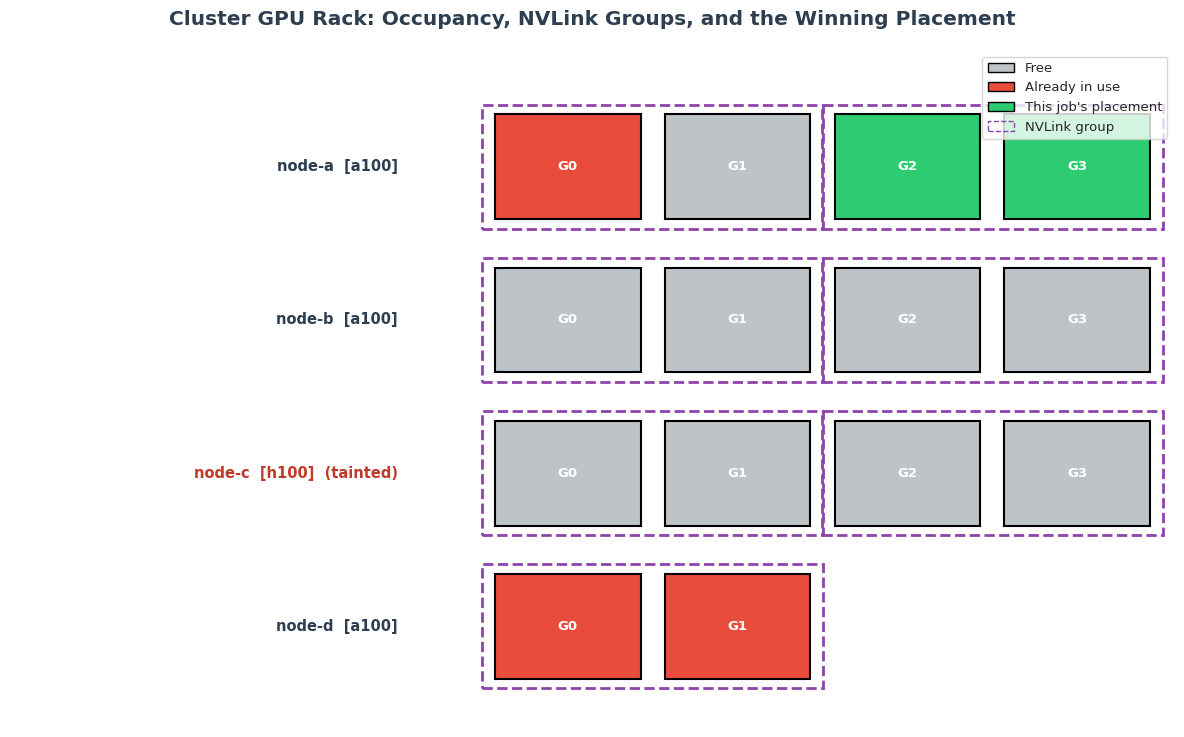

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(12, 7.5))
fig.suptitle("Cluster GPU Rack: Occupancy, NVLink Groups, and the Winning Placement",
             fontsize=14.5, fontweight='bold', color="#2c3e50")
ax.axis("off")

node_names = list(cluster.keys())
row_h, gpu_w, gpu_gap = 1.3, 0.9, 0.15
y_positions = {name: (len(node_names) - 1 - i) * 1.9 for i, name in enumerate(node_names)}

winner_name, winner_gpus = (winner[0], winner[2]) if winner else (None, [])

for name in node_names:
    node = cluster[name]
    y = y_positions[name]
    tainted = len(node["taints"]) > 0
    label = f"{name}  [{node['labels']['gpu-type']}]" + ("  (tainted)" if tainted else "")
    ax.text(-0.6, y + row_h / 2, label, ha="right", va="center", fontsize=10.5, fontweight="bold",
            color="#c0392b" if tainted else "#2c3e50")

    for group in node["nvlink_groups"]:
        x0 = group[0] * (gpu_w + gpu_gap)
        x1 = group[-1] * (gpu_w + gpu_gap) + gpu_w
        ax.add_patch(patches.Rectangle((x0 - 0.08, y - 0.12), (x1 - x0) + 0.16, row_h + 0.24,
                                        fill=False, edgecolor="#8e44ad", lw=2, linestyle="--", zorder=1))

    for g in range(node["gpus"]):
        x = g * (gpu_w + gpu_gap)
        is_used = g in used.get(name, [])
        is_winner_pick = (name == winner_name) and (g in winner_gpus)
        color = "#2ecc71" if is_winner_pick else ("#e74c3c" if is_used else "#bdc3c7")
        ax.add_patch(patches.Rectangle((x, y), gpu_w, row_h, facecolor=color, edgecolor="black", lw=1.5, zorder=2))
        ax.text(x + gpu_w / 2, y + row_h / 2, f"G{g}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white", zorder=3)

legend_elems = [
    patches.Patch(facecolor="#bdc3c7", edgecolor="black", label="Free"),
    patches.Patch(facecolor="#e74c3c", edgecolor="black", label="Already in use"),
    patches.Patch(facecolor="#2ecc71", edgecolor="black", label="This job's placement"),
    patches.Patch(facecolor="none", edgecolor="#8e44ad", linestyle="--", label="NVLink group"),
]
ax.legend(handles=legend_elems, loc="upper right", frameon=True, fontsize=9.5)

ax.set_xlim(-3.0, 4.2)
ax.set_ylim(-0.6, max(y_positions.values()) + row_h + 0.8)
plt.tight_layout()
plt.show()


*(Insight: The purple dashed brackets are NVLink groups -- the scheduler's scoring function actively prefers filling one intact bracket over spanning two, because two GPUs inside the same bracket cost 1 unit to synchronize while two GPUs in different brackets cost 4. Node-c's GPUs sit untouched (grey) not because they were a bad score, but because the filter phase eliminated the node entirely before scoring ever ran -- a taint is a hard veto, not a scoring penalty.)*

## Real-World Use Case or Analogy

Think of topology-aware GPU scheduling as **Assigning Seats for a Team That Needs to Talk Constantly**:

* **A Node (One Conference Table):** Every seat at the same table can lean over and talk to any other seat almost instantly -- the NVLink-connected GPUs on one node.
* **An NVLink Group (Seats Clustered at One End of the Table):** Even within one table, seats clustered together can pass notes fastest; seats at the far end still work, just with slightly more friction -- the PCIe-vs-NVLink distinction within a single node.
* **Cross-Node Placement (Splitting the Team Across Two Buildings):** Technically everyone can still dial in, but every single exchange now goes through a phone line instead of a whisper -- the 16x cost tier for a cross-node link.
* **A Taint (A Room Reserved for a Specific Department):** A "Reserved for Finance" sign on a conference room is a hard rule, not a preference -- nobody without explicit clearance (a toleration) is even considered for that room, no matter how empty it looks.
* **Scoring by Interconnect Cost (Choosing the Best Available Room, Not Just Any Available Room):** Among every room that's actually allowed, the team still picks the one letting them sit closest together, because meeting quality (training throughput) depends on how easily everyone can talk, not merely on headcount fitting through the door.
* **Fragmentation (Twelve Half-Empty Rooms When You Need One Room of Six):** A building can be "60% empty" in aggregate and still be useless to a team of six if every individual room only has one or two free chairs -- capacity that exists on paper but nowhere anyone can actually use it.

The scheduling insight generalizes past GPUs specifically: whenever a resource's *usefulness* depends on which units are grouped together, not just how many units are free, filtering on hard constraints first and scoring on placement quality second is the only way to avoid quietly degrading every job that runs on a "technically available" allocation.